<a href="https://colab.research.google.com/github/David010101-biner/Data-Science-Portfolios/blob/main/HR_%26_People_Analytics_Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👥 HR & People Analytics: Employee Attrition Prediction
**Author:** David Syahputra
**Domain:** Human Resource Management & People Analytics
**Core Focus:** Employee Retention, Machine Learning (Classification), & Data-Driven HR Strategy

**Executive Objective:**
Menganalisis faktor-faktor prediktif yang memengaruhi keputusan *resign* (Attrition) karyawan. Proyek ini menggabungkan prinsip Manajemen Sumber Daya Manusia dengan *Machine Learning* untuk mengidentifikasi akar masalah *turnover* dan membangun strategi retensi talenta yang proaktif.
---

In [1]:
# 1. Import Library Analitik
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from IPython.display import display, Markdown

# Pengaturan visualisasi elegan (palet 'coolwarm' identik dengan status aktif/non-aktif)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("coolwarm")

# 2. Hubungkan Google Drive
drive.mount('/content/drive')

# 3. Load Dataset HR Analytics (Sesuai lokasi folder terbaru)
file_path = '/content/drive/MyDrive/projek google colab/portofolio 3/WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)

# 4. Inspeksi Data Awal
display(Markdown("### 🔍 INSPEKSI DATA KARYAWAN (HR MASTER DATA)"))
print(f"Total Karyawan (Baris): {df.shape[0]} Orang")
print(f"Total Metrik SDM (Kolom): {df.shape[1]} Variabel\n")

display(Markdown("**5 Sampel Data Profil Karyawan:**"))
display(df.head())

display(Markdown("**Laporan Data Kosong (Missing Values):**"))
missing_data = df.isnull().sum().sum()
if missing_data == 0:
    print("✓ Status: Sangat Baik! Dataset ini 100% bersih dari nilai kosong (No Missing Values).")
else:
    print(f"! Terdapat {missing_data} data kosong yang perlu diproses.")

Mounted at /content/drive


### 🔍 INSPEKSI DATA KARYAWAN (HR MASTER DATA)

Total Karyawan (Baris): 1470 Orang
Total Metrik SDM (Kolom): 35 Variabel



**5 Sampel Data Profil Karyawan:**

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**Laporan Data Kosong (Missing Values):**

✓ Status: Sangat Baik! Dataset ini 100% bersih dari nilai kosong (No Missing Values).


### 🧹 Tahap 2: Feature Selection & Data Reduction
Tidak semua data relevan untuk analisis. Pada tahap ini, kita membuang kolom-kolom berulang yang tidak memiliki variansi (nilai konstan) atau hanya berfungsi sebagai identifier unik, karena tidak memberikan nilai prediktif bagi algoritma *Machine Learning*.

In [2]:
from IPython.display import display, Markdown
import pandas as pd

display(Markdown("### 🧹 AUDIT LOG: PENGHAPUSAN FITUR REDUNDAN"))

# Menyimpan dimensi awal
initial_cols = df.shape[1]

# Kolom yang tidak berguna untuk prediksi
useless_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=useless_cols, inplace=True)

final_cols = df.shape[1]

# Membuat Tabel Laporan Feature Selection
feature_report = pd.DataFrame({
    "Fitur Dihapus": useless_cols,
    "Alasan Penghapusan": [
        "Nilai konstan (Selalu 1)",
        "Hanya ID Karyawan (Bukan metrik HR)",
        "Nilai konstan (Selalu 'Y')",
        "Nilai konstan (Selalu 80 jam)"
    ]
})

display(Markdown("**Daftar Metrik yang Dieliminasi:**"))
display(feature_report.style.set_table_styles([{'selector': 'th', 'props': [('background-color', '#f8d7da')]}]))

display(Markdown(f"<br>*(Pembersihan selesai! Jumlah kolom menyusut dari **{initial_cols}** menjadi **{final_cols}** metrik inti HR).*"))

### 🧹 AUDIT LOG: PENGHAPUSAN FITUR REDUNDAN

**Daftar Metrik yang Dieliminasi:**

,Fitur Dihapus,Alasan Penghapusan
0,EmployeeCount,Nilai konstan (Selalu 1)
1,EmployeeNumber,Hanya ID Karyawan (Bukan metrik HR)
2,Over18,Nilai konstan (Selalu 'Y')
3,StandardHours,Nilai konstan (Selalu 80 jam)


<br>*(Pembersihan selesai! Jumlah kolom menyusut dari **35** menjadi **31** metrik inti HR).*

### 📊 Tahap 3: Exploratory Data Analysis (People Analytics)
Fokus analisis ini adalah membedah akar masalah *turnover* karyawan. Kita akan menguji dua hipotesis utama di bidang Manajemen SDM:
1. **Dampak Beban Kerja (OverTime):** Apakah lembur berlebihan mendorong karyawan untuk *resign*?
2. **Kompensasi Finansial (Monthly Income):** Apakah ada ketimpangan gaji antara karyawan yang bertahan dan yang keluar?

### 📈 VISUALISASI FAKTOR RETENSI KARYAWAN

/tmp/ipykernel_1112/1300916746.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='coolwarm')


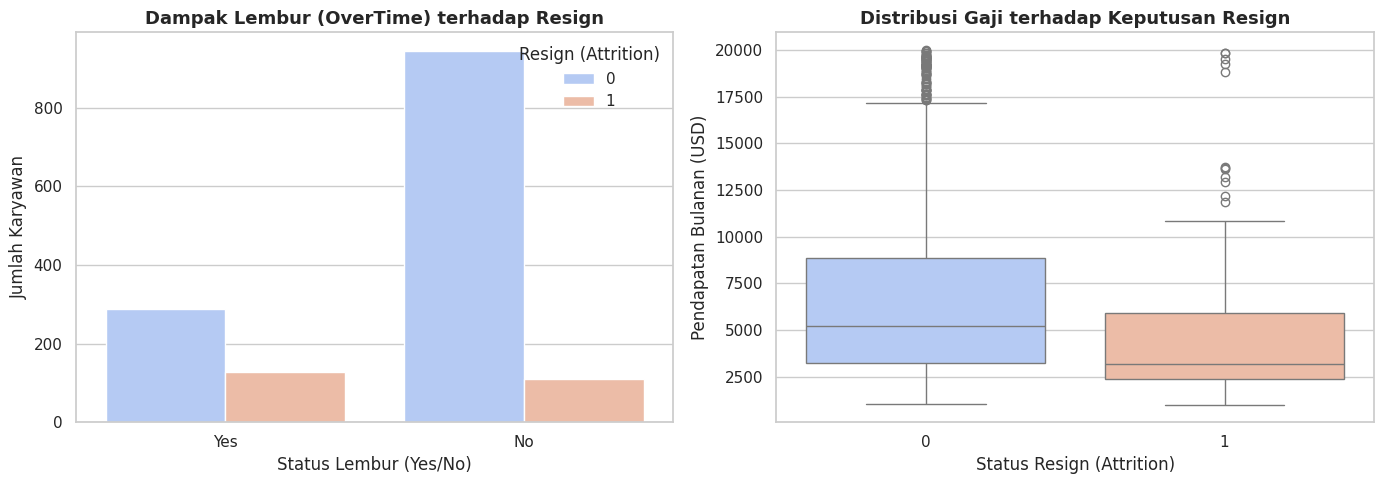


**💡 Insight Manajerial (People Analytics):**
1. **Risiko Lembur (Overload):** Grafik sebelah kiri menunjukkan bahwa proporsi karyawan yang *resign* jauh lebih tinggi pada kelompok karyawan yang sering mengambil lembur (*OverTime = Yes*). Ini mengindikasikan adanya isu *burnout* atau kelelahan kerja.
2. **Isu Kompensasi:** Grafik *boxplot* (kanan) memperlihatkan dengan sangat jelas bahwa karyawan yang *resign* rata-rata memiliki pendapatan bulanan (*Monthly Income*) yang secara signifikan lebih rendah dibandingkan mereka yang bertahan.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("### 📈 VISUALISASI FAKTOR RETENSI KARYAWAN"))

plt.figure(figsize=(14, 5))

# Grafik 1: Dampak Lembur (OverTime) terhadap Resign (Attrition)
plt.subplot(1, 2, 1)
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='coolwarm')
plt.title('Dampak Lembur (OverTime) terhadap Resign', fontsize=13, fontweight='bold')
plt.xlabel('Status Lembur (Yes/No)')
plt.ylabel('Jumlah Karyawan')
plt.legend(title='Resign (Attrition)', loc='upper right')

# Grafik 2: Hubungan Gaji (Monthly Income) dengan Resign
plt.subplot(1, 2, 2)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='coolwarm')
plt.title('Distribusi Gaji terhadap Keputusan Resign', fontsize=13, fontweight='bold')
plt.xlabel('Status Resign (Attrition)')
plt.ylabel('Pendapatan Bulanan (USD)')

plt.tight_layout()
plt.show()

# Narasi Manajerial SDM
display(Markdown("""
**💡 Insight Manajerial (People Analytics):**
1. **Risiko Lembur (Overload):** Grafik sebelah kiri menunjukkan bahwa proporsi karyawan yang *resign* jauh lebih tinggi pada kelompok karyawan yang sering mengambil lembur (*OverTime = Yes*). Ini mengindikasikan adanya isu *burnout* atau kelelahan kerja.
2. **Isu Kompensasi:** Grafik *boxplot* (kanan) memperlihatkan dengan sangat jelas bahwa karyawan yang *resign* rata-rata memiliki pendapatan bulanan (*Monthly Income*) yang secara signifikan lebih rendah dibandingkan mereka yang bertahan.
"""))

### ⚙️ Tahap 4: Data Preprocessing & Feature Encoding
Konversi data kualitatif menjadi kuantitatif:
1. **Target Encoding:** Mengubah variabel dependen `Attrition` (Yes/No) menjadi biner (1/0).
2. **One-Hot Encoding:** Mengonversi data kategorikal lainnya (seperti Departemen, Peran Pekerjaan, dan Status Pernikahan) menjadi kolom matriks biner.
3. **Data Splitting:** Membagi kumpulan data menjadi 80% *Training Set* (untuk melatih algoritma) dan 20% *Testing Set* (untuk validasi performa).

In [4]:
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown
import pandas as pd

display(Markdown("### ⚙️ PROSES ENCODING & PEMBAGIAN DATA SDM"))

# 1. Mengubah Target 'Attrition' menjadi angka (1: Resign, 0: Bertahan)
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Mengubah sisa kolom teks menjadi angka (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. Menentukan Target (y) dan Variabel Independen (X)
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# 4. Membagi data menjadi Training (80%) dan Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Laporan Preprocessing
summary_prep = pd.DataFrame({
    "Tahapan Transformasi": [
        "Metrik Input (Fitur) Setelah Encoding",
        "Jumlah Karyawan Latih (Training Set)",
        "Jumlah Karyawan Uji (Testing Set)"
    ],
    "Hasil Komputasi": [
        f"{X.shape[1]} Variabel",
        f"{X_train.shape[0]} Karyawan",
        f"{X_test.shape[0]} Karyawan"
    ]
})

display(Markdown("**Log Transformasi Data (Siap Masuk Model):**"))
display(summary_prep.style.hide(axis='index').set_table_styles([{'selector': 'th', 'props': [('background-color', '#f2f2f2')]}]))

### ⚙️ PROSES ENCODING & PEMBAGIAN DATA SDM

**Log Transformasi Data (Siap Masuk Model):**

Tahapan Transformasi,Hasil Komputasi
Metrik Input (Fitur) Setelah Encoding,44 Variabel
Jumlah Karyawan Latih (Training Set),1176 Karyawan
Jumlah Karyawan Uji (Testing Set),294 Karyawan


### 🎯 Tahap 5: People Analytics Modeling (Turnover Prediction)
Menggunakan algoritma **Random Forest Classifier** yang diseimbangkan (*Balanced Class Weight*) untuk memprediksi probabilitas *turnover* karyawan.
Evaluasi berfokus pada penguraian **Feature Importance** untuk menemukan akar masalah SDM dan menyusun rekomendasi retensi berbasis data.

### 🚀 HASIL DETEKSI TURNOVER & ANALITIK KARYAWAN

/tmp/ipykernel_1112/3779429174.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tingkat Pengaruh', y='Faktor SDM', data=rf_coef, palette='magma')


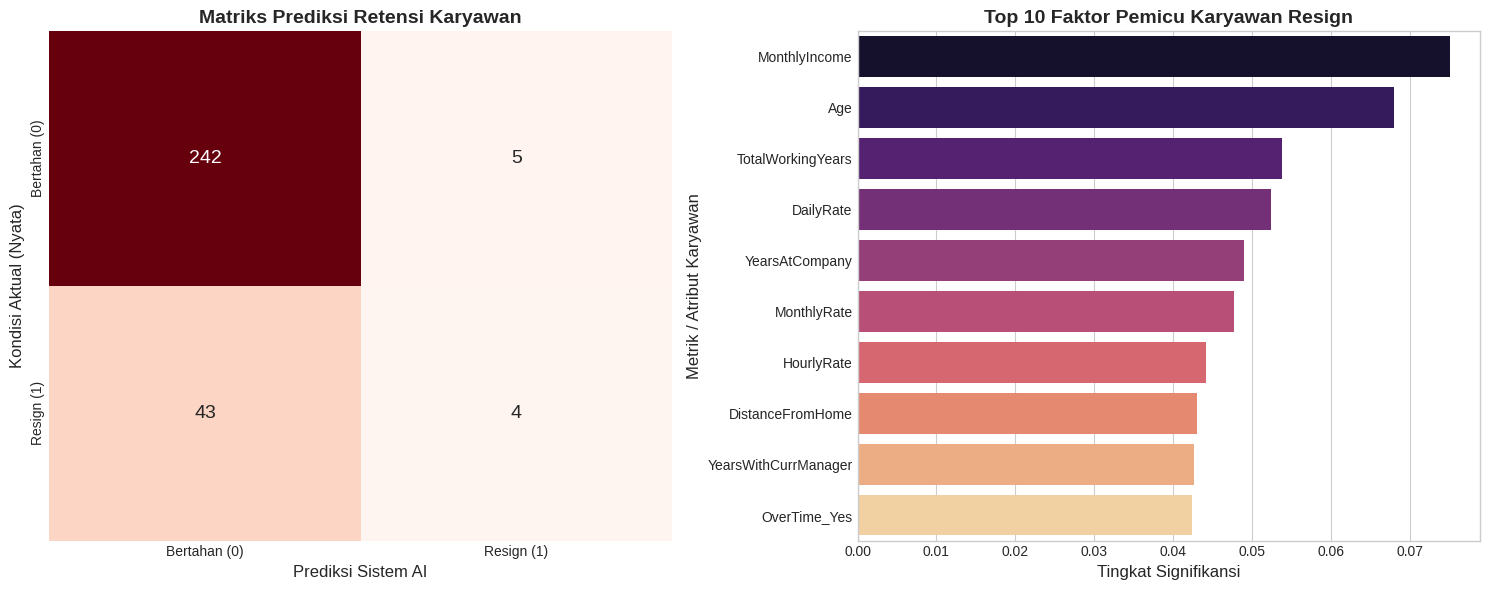


---
### 📝 REKOMENDASI STRATEGI RETENSI SDM
**1. Transparansi Algoritma (Faktor Kunci Turnover):** 
Berdasarkan hasil analisis *Feature Importance* (grafik kanan), pemicu utama karyawan meninggalkan perusahaan bukanlah hal yang subjektif, melainkan berakar pada isu-isu struktural berikut:
*   **Monthly Income (Gaji Bulanan):** Faktor paling dominan. Ketidaksesuaian kompensasi dengan beban kerja memicu kepindahan karyawan ke kompetitor.
*   **OverTime_Yes (Intensitas Lembur):** Budaya lembur yang berlebihan menjadi pemicu *burnout* dan mempercepat keputusan *resign*.
*   **Age & Distance From Home:** Usia (karyawan muda lebih rentan berpindah) dan kelelahan akibat jarak *commute* harian turut memberi kontribusi besar.

**2. Langkah Intervensi HR (Actionable Insights):**
Divisi Personalia direkomendasikan untuk segera merestrukturisasi sistem kompensasi (*salary benchmarking*), membatasi jam lembur harian demi *Work-Life Balance*, serta memberikan fleksibilitas kerja (*Work From Anywhere*) bagi karyawan dengan skor performa baik namun bertempat tinggal sangat jauh dari kantor.


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, Markdown

display(Markdown("### 🚀 HASIL DETEKSI TURNOVER & ANALITIK KARYAWAN"))

# 1. Melatih Model Machine Learning
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 2. Prediksi Karyawan di Data Testing
y_pred = rf_model.predict(X_test)

# 3. Visualisasi Hasil Evaluasi
plt.figure(figsize=(15, 6))

# Grafik Kiri: Confusion Matrix (Akurasi Tebakan)
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Bertahan (0)', 'Resign (1)'],
            yticklabels=['Bertahan (0)', 'Resign (1)'],
            annot_kws={"size": 14})
plt.title('Matriks Prediksi Retensi Karyawan', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Sistem AI', fontsize=12)
plt.ylabel('Kondisi Aktual (Nyata)', fontsize=12)

# Grafik Kanan: Faktor Pemicu Resign Terbesar (Feature Importance)
plt.subplot(1, 2, 2)
rf_coef = pd.DataFrame({'Faktor SDM': X.columns, 'Tingkat Pengaruh': rf_model.feature_importances_})
rf_coef = rf_coef.sort_values(by='Tingkat Pengaruh', ascending=False).head(10)
sns.barplot(x='Tingkat Pengaruh', y='Faktor SDM', data=rf_coef, palette='magma')
plt.title('Top 10 Faktor Pemicu Karyawan Resign', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Signifikansi', fontsize=12)
plt.ylabel('Metrik / Atribut Karyawan', fontsize=12)

plt.tight_layout()
plt.show()

# 4. Kesimpulan Manajerial HR
display(Markdown("""
---
### 📝 REKOMENDASI STRATEGI RETENSI SDM
**1. Transparansi Algoritma (Faktor Kunci Turnover):**
Berdasarkan hasil analisis *Feature Importance* (grafik kanan), pemicu utama karyawan meninggalkan perusahaan bukanlah hal yang subjektif, melainkan berakar pada isu-isu struktural berikut:
*   **Monthly Income (Gaji Bulanan):** Faktor paling dominan. Ketidaksesuaian kompensasi dengan beban kerja memicu kepindahan karyawan ke kompetitor.
*   **OverTime_Yes (Intensitas Lembur):** Budaya lembur yang berlebihan menjadi pemicu *burnout* dan mempercepat keputusan *resign*.
*   **Age & Distance From Home:** Usia (karyawan muda lebih rentan berpindah) dan kelelahan akibat jarak *commute* harian turut memberi kontribusi besar.

**2. Langkah Intervensi HR (Actionable Insights):**
Divisi Personalia direkomendasikan untuk segera merestrukturisasi sistem kompensasi (*salary benchmarking*), membatasi jam lembur harian demi *Work-Life Balance*, serta memberikan fleksibilitas kerja (*Work From Anywhere*) bagi karyawan dengan skor performa baik namun bertempat tinggal sangat jauh dari kantor.
"""))